In [2]:
import copy

import scipy.io as sio
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error
import matplotlib.pyplot as plt
import random

data = sio.loadmat('Xtrain.mat')
print(data['Xtrain'].shape)

series = np.array(data['Xtrain']).squeeze().astype(np.float32)
print(series.shape)
print(series[:10])

(1000, 1)
(1000,)
[ 86. 141.  95.  41.  22.  21.  32.  72. 138. 111.]


In [3]:
scaler = StandardScaler()
series_scaled = scaler.fit_transform(series.reshape(-1, 1)).squeeze()
print(series_scaled[:10])
print("Scaled shape:", series_scaled.shape)

[ 0.55720156  1.7311113   0.74929583 -0.40327    -0.8088024  -0.83014625
 -0.59536433  0.25838816  1.6670799   1.0907968 ]
Scaled shape: (1000,)


In [4]:
class TimeSeriesDataset(Dataset):
    def __init__(self, series, window_size):
        self.series = series
        self.window_size = window_size

    def __len__(self):
        return len(self.series) - self.window_size

    def __getitem__(self, idx):
        x = self.series[idx : idx + self.window_size]
        y = self.series[idx + self.window_size]

        # GRU input shape: [seq_len, input_size]
        x = torch.tensor(x, dtype=torch.float32).unsqueeze(-1)
        y = torch.tensor(y, dtype=torch.float32)

        return x, y

In [5]:
class GRUModel(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1, dropout=0.0):
        super(GRUModel, self).__init__()

        self.gru = nn.GRU(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0
        )

        self.fc = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, hidden = self.gru(x)

        last_out = out[:, -1, :]

        y_pred = self.fc(last_out)

        return y_pred.squeeze(-1)

In [6]:
train_ratio = 0.8
split_idx = int(len(series_scaled) * train_ratio)

train_series = series_scaled[:split_idx]
val_series = series_scaled[split_idx:]

print("Train length:", len(train_series))
print("Val length:", len(val_series))

Train length: 800
Val length: 200


In [7]:
def train_gru(
    train_series,
    val_series,
    seed,
    window_size=25,
    hidden_size=64,
    num_layers=1,
    lr=0.001,
    batch_size=64,
    epochs=100
):

    device = torch.device("cpu")

    train_dataset = TimeSeriesDataset(train_series, window_size)
    val_dataset = TimeSeriesDataset(val_series, window_size)

    g = torch.Generator()
    g.manual_seed(seed)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True,generator=g)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

    model = GRUModel(
        input_size=1,
        hidden_size=hidden_size,
        num_layers=num_layers,
        output_size=1
    ).to(device)

    criterion = nn.MSELoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    best_val_loss = float("inf")
    best_model_state = None

    train_losses = []
    val_losses = []
    idx = 1
    for epoch in range(epochs):
        model.train()
        total_train_loss = 0.0

        for x_batch, y_batch in train_loader:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            y_pred = model(x_batch)
            loss = criterion(y_pred, y_batch)

            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * x_batch.size(0)

        avg_train_loss = total_train_loss / len(train_dataset)

        model.eval()
        total_val_loss = 0.0

        with torch.no_grad():
            for x_batch, y_batch in val_loader:
                x_batch = x_batch.to(device)
                y_batch = y_batch.to(device)

                y_pred = model(x_batch)
                loss = criterion(y_pred, y_batch)

                total_val_loss += loss.item() * x_batch.size(0)

        avg_val_loss = total_val_loss / len(val_dataset)

        train_losses.append(avg_train_loss)
        val_losses.append(avg_val_loss)

        if avg_val_loss < best_val_loss:
            best_val_loss = avg_val_loss
            best_epoch = idx
            best_model_state = copy.deepcopy(model.state_dict())
        idx += 1
    model.load_state_dict(best_model_state)

    return model, train_losses, val_losses, best_val_loss, best_epoch

In [8]:
def recursive_forecast(model, history_scaled, window_size, steps=200):
    device = next(model.parameters()).device
    model.eval()

    history = list(history_scaled.copy())
    predictions = []

    with torch.no_grad():
        for _ in range(steps):
            x = np.array(history[-window_size:], dtype=np.float32)

            x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)

            next_pred = model(x_tensor).item()

            predictions.append(next_pred)
            history.append(next_pred)

    return np.array(predictions)

In [9]:
def predict_one_step(model, series_scaled, window_size):
    device = next(model.parameters()).device
    model.eval()

    preds = []
    targets = []

    with torch.no_grad():
        for i in range(len(series_scaled) - window_size):
            x = series_scaled[i : i + window_size]
            y_true = series_scaled[i + window_size]

            x_tensor = torch.tensor(x, dtype=torch.float32).unsqueeze(0).unsqueeze(-1).to(device)

            y_pred = model(x_tensor).item()

            preds.append(y_pred)
            targets.append(y_true)

    preds = np.array(preds)
    targets = np.array(targets)

    return preds, targets

In [10]:
window_sizes = range(10,20)
learning_rates = [0.0001, 0.001, 0.01, 0.1]
seeds = [42, 1, 2]
grid_results = {}
total = len(window_sizes) * len(learning_rates)
counter = 0

for ws in window_sizes:
    for lr in learning_rates:
        counter += 1
        print("=" * 60)
        print(f"[{counter}/{total}] window_size={ws}, lr={lr}")
        print("=" * 60)

        recursive_mses = []
        for seed in seeds:
            random.seed(seed)
            np.random.seed(seed)
            torch.manual_seed(seed)

            model_tmp, _, _, single_step_val_loss,_ = train_gru(
                train_series=train_series,
                val_series=val_series,
                window_size=ws,
                seed=seed,
                hidden_size=64,
                num_layers=1,
                lr=lr,
                batch_size=64,
                epochs=80
            )
            recursive_steps = len(val_series)
            recursive_preds = recursive_forecast(
                model=model_tmp,
                history_scaled=train_series,
                window_size=ws,
                steps=recursive_steps
            )
            recursive_mse = np.mean((recursive_preds - val_series) ** 2)
            recursive_mses.append(recursive_mse)
            print(f"seed={seed}, recursive_mse={recursive_mse:.6f}")
        grid_results[(ws, lr)] = {
            "recursive_mse_mean":   np.mean(recursive_mses),
            "recursive_mse_std":    np.std(recursive_mses),
            "recursive_mse":   recursive_mses
        }
        print(f"mean recursive MSE: {np.mean(recursive_mses):.6f} +/- {np.std(recursive_mses):.6f}")

[1/40] window_size=10, lr=0.0001
seed=42, recursive_mse=2.660710
seed=1, recursive_mse=2.612975
seed=2, recursive_mse=2.522163
mean recursive MSE: 2.598616 +/- 0.057466
[2/40] window_size=10, lr=0.001
seed=42, recursive_mse=0.889655
seed=1, recursive_mse=0.625514
seed=2, recursive_mse=1.116263
mean recursive MSE: 0.877144 +/- 0.200542
[3/40] window_size=10, lr=0.01
seed=42, recursive_mse=9.935550
seed=1, recursive_mse=2.095346
seed=2, recursive_mse=1.336613
mean recursive MSE: 4.455836 +/- 3.887104
[4/40] window_size=10, lr=0.1
seed=42, recursive_mse=1.313215
seed=1, recursive_mse=0.990451
seed=2, recursive_mse=1.182273
mean recursive MSE: 1.161980 +/- 0.132547
[5/40] window_size=11, lr=0.0001
seed=42, recursive_mse=2.771550
seed=1, recursive_mse=2.800822
seed=2, recursive_mse=2.782010
mean recursive MSE: 2.784794 +/- 0.012111
[6/40] window_size=11, lr=0.001
seed=42, recursive_mse=0.722945
seed=1, recursive_mse=0.573457
seed=2, recursive_mse=0.726252
mean recursive MSE: 0.674218 +/- 0.

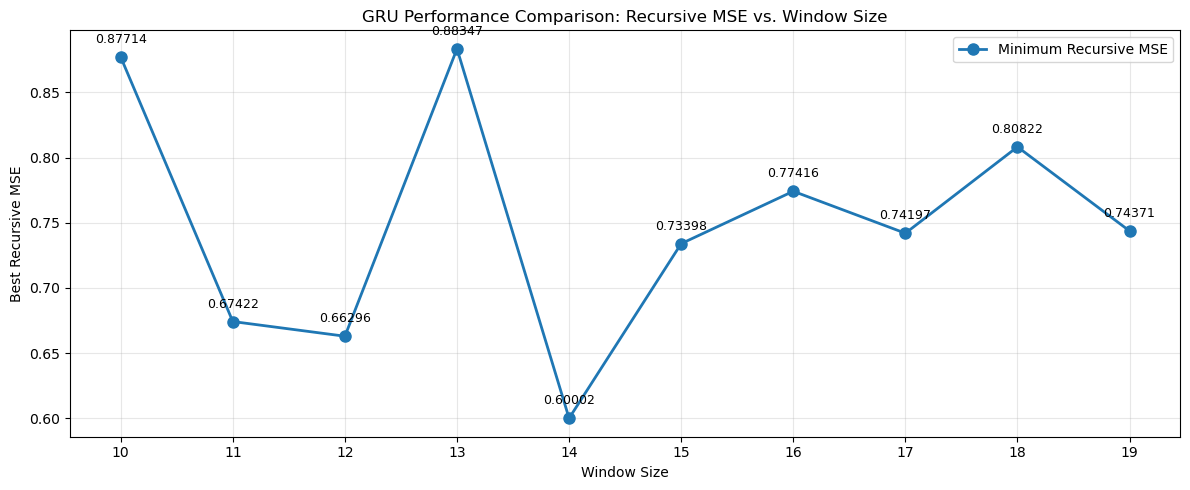

In [11]:
window_sizes = sorted(set(ws for (ws, lr) in grid_results.keys()))

best_mse_per_ws = []
for ws in window_sizes:
    mses = [grid_results[(ws, lr)]["recursive_mse_mean"]
            for (w, lr) in grid_results.keys() if w == ws]
    best_mse_per_ws.append(min(mses))

plt.figure(figsize=(12, 5))
plt.plot(window_sizes, best_mse_per_ws, marker='o', linewidth=2,
         markersize=8, label='Minimum Recursive MSE')

for x, y in zip(window_sizes, best_mse_per_ws):
    plt.annotate(f'{y:.5f}', xy=(x, y), xytext=(0, 10),
                 textcoords='offset points', ha='center', fontsize=9)

plt.xlabel('Window Size')
plt.ylabel('Best Recursive MSE')
plt.title('GRU Performance Comparison: Recursive MSE vs. Window Size')
plt.xticks(window_sizes)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.savefig('output/gru_seq_length_comparison.png')
plt.show()

In [12]:
print(f"{'ws':>4} | {'lr':>8} | {'recursive MSE':>18}")
for (ws, lr), m in grid_results.items():
    rc = f"{m['recursive_mse_mean']:.6f} ± {m['recursive_mse_std']:.6f}"

best_params = min(grid_results, key=lambda k: grid_results[k]["recursive_mse_mean"])
best_ws, best_lr = best_params

print(f"best parameters:window_size={best_ws}, lr={best_lr}")
print(f"mean recursive MSE: {grid_results[best_params]['recursive_mse_mean']:.6f} "
      f"± {grid_results[best_params]['recursive_mse_std']:.6f}")

  ws |       lr |      recursive MSE
best parameters:window_size=14, lr=0.001
mean recursive MSE: 0.600017 ± 0.217742


## single step prediction

In [13]:
seeds = [42,1,2]
ensemble_single_models = []
all_single_train_losses = []
all_single_val_losses = []
best_single_epochs = []
for seed in seeds:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    model, train_losses, val_losses, best_val_loss,best_epoch = train_gru(
        train_series=train_series,
        val_series=val_series,
        seed=seed,
        window_size=best_ws,
        hidden_size=64,
        num_layers=1,
        lr=best_lr,
        batch_size=64,
        epochs=100
    )

    ensemble_single_models.append(model)
    all_single_train_losses.append(train_losses)
    all_single_val_losses.append(val_losses)
    best_single_epochs.append(best_epoch)
    print(f"seed={seed}, val_loss={best_val_loss:.6f}")

seed=42, val_loss=0.001256
seed=1, val_loss=0.001601
seed=2, val_loss=0.001303


In [14]:
all_val_single_preds_scaled = []
for model in ensemble_single_models:
    val_preds_scaled, val_targets_scaled = predict_one_step(
        model=model,
        series_scaled=val_series,
        window_size=best_ws
    )
    all_val_single_preds_scaled.append(val_preds_scaled)
ensemble_single_val_preds_scaled = np.mean(all_val_single_preds_scaled,axis=0)
# scale back
ensemble_single_val_preds = scaler.inverse_transform(ensemble_single_val_preds_scaled.reshape(-1, 1)).squeeze()
val_targets = scaler.inverse_transform(val_series[best_ws:].reshape(-1, 1)).squeeze()

mae_single = mean_absolute_error(val_targets, ensemble_single_val_preds)
mse_single = mean_squared_error(val_targets, ensemble_single_val_preds)

print("Validation MAE:", mae_single)
print("Validation MSE:", mse_single)

Validation MAE: 1.1877112748834273
Validation MSE: 2.35620946893001


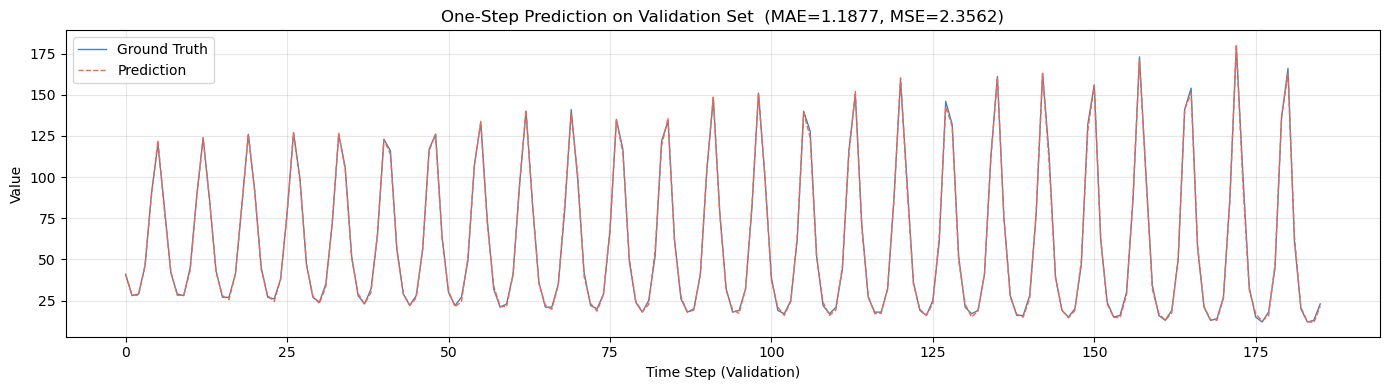

In [15]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(val_targets,    label='Ground Truth', color='steelblue', linewidth=1)
ax.plot(ensemble_single_val_preds, label='Prediction',   color='tomato',    linewidth=1, linestyle='--')
ax.set_xlabel('Time Step (Validation)')
ax.set_ylabel('Value')
ax.set_title(f'One-Step Prediction on Validation Set  '
             f'(MAE={mae_single:.4f}, MSE={mse_single:.4f})')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/gru_plot2_onestep_val.png', dpi=150)
plt.show()

## final ensemble models
make full use of train set to train a better model under optimal hyperparameters

In [16]:
seeds = [42,1,2]
ensemble_models = []
all_train_losses = []
all_val_losses = []
best_epochs = []
for seed in seeds:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    model, train_losses, val_losses, best_val_loss,best_epoch = train_gru(
        train_series=series_scaled[:950],
        val_series=series_scaled[950:],
        seed=seed,
        window_size=best_ws,
        hidden_size=64,
        num_layers=1,
        lr=best_lr,
        batch_size=64,
        epochs=100
    )

    ensemble_models.append(model)
    all_train_losses.append(train_losses)
    all_val_losses.append(val_losses)
    best_epochs.append(best_epoch)
    print(f"seed={seed}, val_loss={best_val_loss:.6f}")

seed=42, val_loss=0.000900
seed=1, val_loss=0.001386
seed=2, val_loss=0.001804


[0.95406876 0.83205051 0.61701103 0.32020304 0.22502324 0.17414651
 0.14859866 0.13906524 0.13091522 0.1177159  0.10883964 0.1085704
 0.10107333 0.09249398 0.0866516  0.08598317 0.08180217 0.07648082
 0.07290179 0.07025606 0.06814295 0.06435783 0.06017349 0.05831264
 0.05798397 0.05762718 0.05852484 0.05487589 0.05116681 0.0527475
 0.049466   0.04861272 0.05160752 0.0504368  0.04768392 0.04276976
 0.04082225 0.04107451 0.03936433 0.03997768 0.03819782 0.03962607
 0.03761821 0.03870017 0.03528725 0.03535038 0.03294844 0.03174302
 0.0312963  0.03183134 0.03096033 0.02931286 0.02878252 0.03089367
 0.03275538 0.03382247 0.02959619 0.02776637 0.02683701 0.02684903
 0.02570548 0.02493503 0.02582056 0.02449065 0.02436403 0.02771018
 0.02652815 0.02452077 0.02267642 0.02391267 0.02577947 0.02182713
 0.02168931 0.01993878 0.02026957 0.02186551 0.02210425 0.02242126
 0.02040786 0.01983735 0.01849915 0.02029826 0.02185656 0.01843656
 0.01672978 0.01653824 0.01676564 0.01825645 0.01768637 0.018280

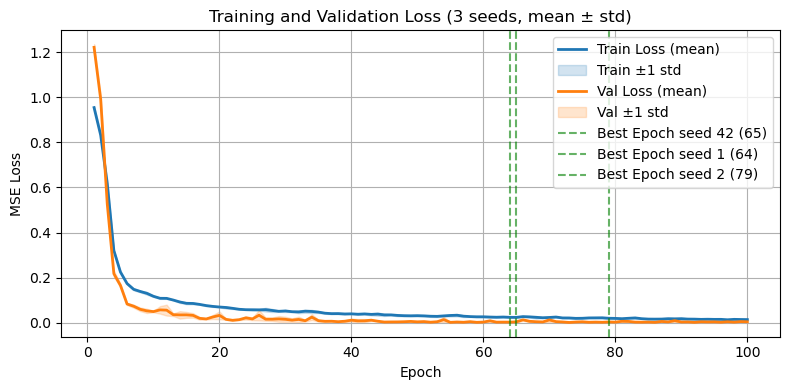

In [17]:
train_arr = np.array([l for l in all_train_losses])
val_arr   = np.array([l for l in all_val_losses])

train_mean, train_std = train_arr.mean(0), train_arr.std(0)
val_mean,   val_std   = val_arr.mean(0),   val_arr.std(0)

print(train_mean)
print(val_mean)
epochs = np.arange(1, 101)

plt.figure(figsize=(8, 4))
plt.plot(epochs, train_mean, label='Train Loss (mean)', color='tab:blue', linewidth=2)
plt.fill_between(epochs, train_mean - train_std, train_mean + train_std,
                 alpha=0.2, color='tab:blue', label='Train ±1 std')

plt.plot(epochs, val_mean, label='Val Loss (mean)', color='tab:orange', linewidth=2)
plt.fill_between(epochs, val_mean - val_std, val_mean + val_std,
                 alpha=0.2, color='tab:orange', label='Val ±1 std')
for i, be in enumerate(best_epochs):
    plt.axvline(x=be, color='green', linestyle='--', linewidth=1.5, alpha=0.6,
                label=f'Best Epoch seed {seeds[i]} ({be})')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.title(f'Training and Validation Loss ({len(seeds)} seeds, mean ± std)')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('output/gru_plot1_loss_curve.png', dpi=300)
plt.show()

In [18]:
all_preds_scaled = []
for model in ensemble_models:
    future_preds_scaled = recursive_forecast(
        model=model,
        history_scaled=series_scaled,
        steps=200,
        window_size=best_ws,
    )
    all_preds_scaled.append(future_preds_scaled)
ensemble_preds_scaled = np.mean(all_preds_scaled, axis=0)
ensemble_preds = scaler.inverse_transform(ensemble_preds_scaled.reshape(-1, 1)).squeeze()

In [21]:
test_data = sio.loadmat('Xtest.mat')
print(test_data['Xtest'].shape)

test_series = np.array(test_data['Xtest']).squeeze().astype(np.float32)
print(series.shape)
print(series[:10])

(200, 1)
(1000,)
[ 86. 141.  95.  41.  22.  21.  32.  72. 138. 111.]


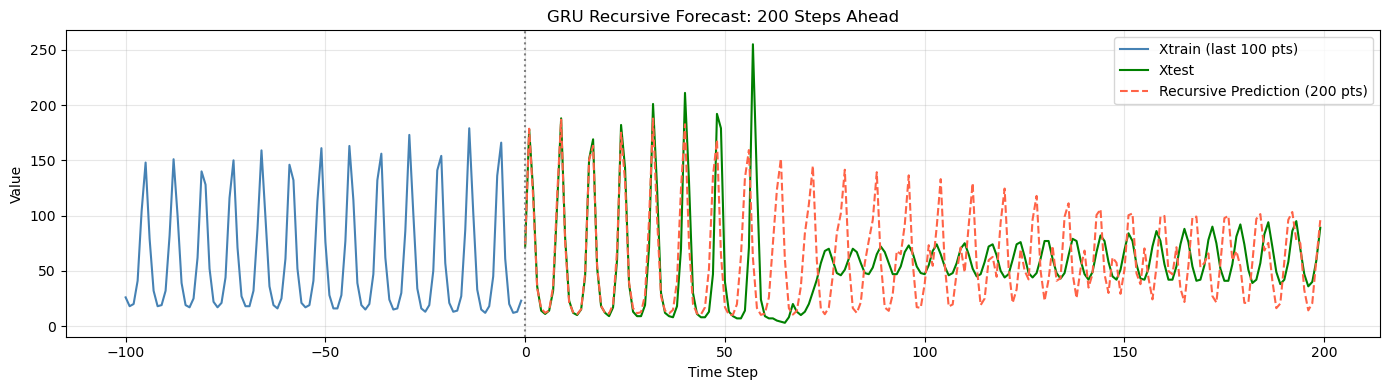

In [26]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(np.arange(-100,0), series[-100:], label='Xtrain (last 100 pts)', color='steelblue')
ax.plot(np.arange(0,len(test_series)), test_series, label='Xtest', color='green')
ax.plot(np.arange(0,200), ensemble_preds, label='Recursive Prediction (200 pts)',
        color='tomato', linestyle='--')
ax.axvline(x=0, color='gray', linestyle=':', linewidth=1.5)
ax.set_xlabel('Time Step')
ax.set_ylabel('Value')
ax.set_title('GRU Recursive Forecast: 200 Steps Ahead')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/gru_plot3_recursive_forecast.png', dpi=150)
plt.show()

In [23]:
mae200 = mean_absolute_error(series[800:], ensemble_preds)
mse200 = mean_squared_error(series[800:], ensemble_preds)

print(f"MAE200: {mae200:.6f}")
print(f"MSE200: {mse200:.6f}")

MAE200: 50.917611
MSE200: 3945.390273


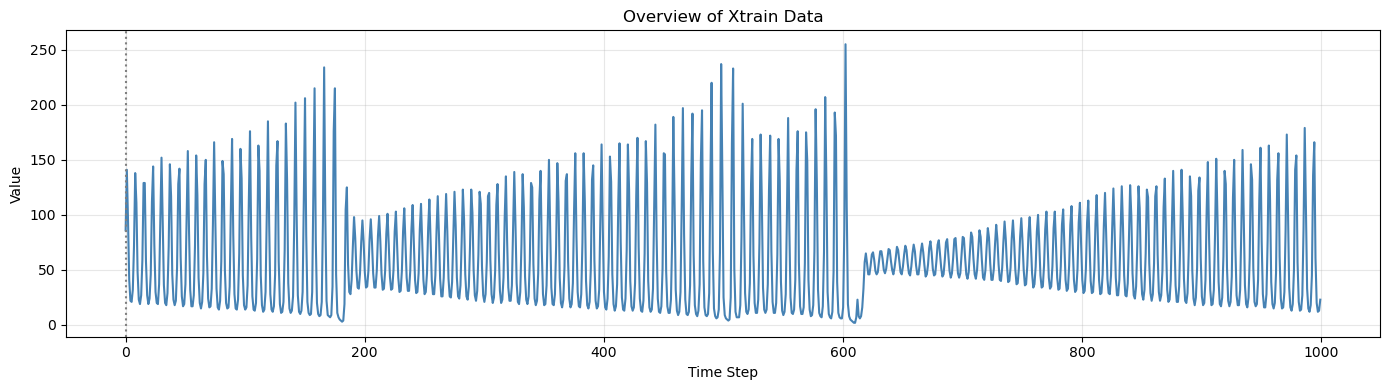

In [29]:
fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(np.arange(0,1000), series, color='steelblue')
ax.axvline(x=0, color='gray', linestyle=':', linewidth=1.5)
ax.set_xlabel('Time Step')
ax.set_ylabel('Value')
ax.set_title('Overview of Xtrain Data')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/Xtest.png', dpi=150)
plt.show()